# Генерация русской поэзии: обучение LSTM на датасете Ars Poetica

### Описание: 

1. Датасет [Ars Poetica](https://huggingface.co/datasets/inkoziev/ArsPoetica) (русская поэзия с расставленными ударениями)

Датасет включает $\approx 8.5$ тыс. русских стихотворений с акцентуацией, размеченной [Russian Poetry Scansion Tool](https://github.com/Koziev/RussianPoetryScansionTool). У каждого объекта 4 поля:

- `author` — автор;
- `title` — название;
- `poem_text` — обычный текст стихотворения;
- `accentuation` — тот же текст, но помечены ударные гласные и акценты в стихотворении.

Модель обучается _с ударениями_ (поле `accentuation`), так как они входят в сам алфавит модели $-$ это должно помогать ей неявно учить размер и рифму.


In [2]:
import os
import json
import math
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import warnings

from tqdm.auto import tqdm
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)
from datasets import load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)



In [3]:
dataset = load_dataset("inkoziev/ArsPoetica")
print(dataset)

train_data = dataset["train"]
print("Количество стихотворений:", len(train_data))
print("Пример:")
print(train_data[0])


DatasetDict({
    train: Dataset({
        features: ['author', 'title', 'poem_text', 'accentuation'],
        num_rows: 8498
    })
})
Количество стихотворений: 8498
Пример:
{'author': 'Николай Гумилёв', 'title': 'Аннам', 'poem_text': 'Месяц стоит посредине\nДивно-огромного неба,\nВетер в бамбуковой чаще,\nБлагоухающий воздух,\nБлагословенна семья.\n\nСтаршие в роще за чаем,\nПьют и стихи повторяют,\nИз дому слышно гуденье,\nТам занимаются дети,\nНоворождённый кричит.\n\nТот, кто живёт этой жизнью,\nПолное знает блаженство.\nЧто ему деньги и слава,\nЕсли он верит, что детям\nДолжно его пережить?', 'accentuation': 'Ме́сяц стои́т посреди́не\nДи́вно - огро́много не́ба,\nВе́тер в бамбу́ковой ча́ще,\nБла̀гоуха́ющий во́здух,\nБлагослове́нна семья́.\n\nСта́ршие в ро́ще за ча́ем,\nПью́т и стихи́ повторя́ют,\nИ́з дому слы́шно гуде́нье,\nТа́м занима́ются де́ти,\nНо̀ворождё́нный кричи́т.\n\nТо́т, кто живё́т этой жи́знью,\nПо́лное зна́ет блаже́нство.\nЧто́ ему де́ньги и сла́ва,\nЕ́сли он ве́рит, 

Характеристики длин стихотворений (по символам):

Минимальная длина: 36
Максимальная длина: 4263
mean: 443 median: 400


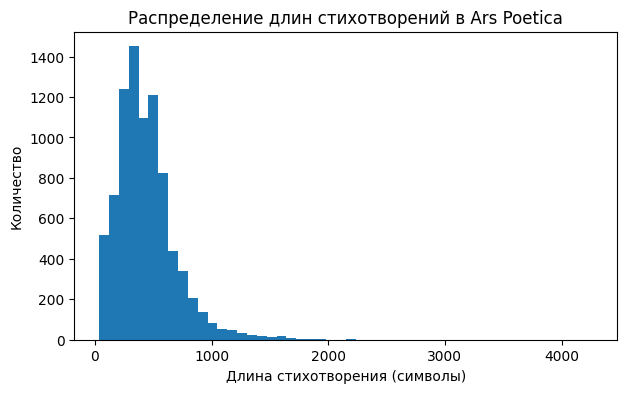


Пример с проставленными ударениями:

Царь сказа́л своему́ полково́дцу: " Могу́чий,
Ты высо́к, точно сло́н дагоме́йских лесо́в,
Но ты все́-таки ни́же торже́ственной ку́чи
Отсечё́нных тобо́й челове́чьих голо́в.

И, как до́блесть твоя́, о, испы́танный во́ин,
Так и ми́лость моя́ не име́ет конца́.
Видишь со́лнце над мо́рем? Ступа́й! Ты досто́ин
Быть слуго́й моего́ золото́го отца́ ".

Бараба́ны заби́ли, защё́лкали бу́бны,
Преклонё́нные лю́ди завы́ли вокру́г,
Амазо́нки запе́ли протя́жно, и тру́бный
Прокати́лся по мо́рю от бе́рега зву́к.

Полково́дец царю́ поклони́лся в молча́ньи
И с утё́са в бурли́вую во́ду прыгнул,
И тону́л он в воде́, а каза́лось, в сия́ньи
Золото́го зака́тного со́лнца тону́л.

Оглуша́ли его́ бараба́ны и кли́ки,
Ослепля́ли солё́ные бры́зги волны́,
Он исче́з. И блесте́ло лицо́ у влады́ки,
Точно чё́рное со́лнце подзе́мной страны́.


In [6]:
lengths = [len(x) for x in train_data["accentuation"]]
print("Характеристики длин стихотворений (по символам):\n")

print('Минимальная длина:', min(lengths))
print('Максимальная длина:', max(lengths))
print("mean:", int(np.mean(lengths)), 'median:', int(np.median(lengths)))

plt.figure(figsize=(7, 4))
plt.hist(lengths, bins=50)
plt.xlabel("Длина стихотворения (символы)")
plt.ylabel("Количество")
plt.title("Распределение длин стихотворений в Ars Poetica")
plt.show()

print("\nПример с проставленными ударениями:\n")
print(train_data[4]["accentuation"])



`SUBSET_SIZE` $-$ сколько объектов берется для обучения. 


In [18]:
# параметры обучения
SUBSET_SIZE = 8400
MAX_CHARS = 400 # обрезаем очень длинные стихи 
BATCH_SIZE = 64
EPOCHS = 80
LR = 1e-3

EMB_DIM = 128
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.3


## Подготовка текста для обучения

Перед обучением LSTM текст необходимо преобразовать в формат, понятный нейронной сети. Поскольку модель работает только с числами, каждый символ текста заменяется на соответствующий числовой индекс.

Основные этапы подготовки:

1. Из датасета извлекаются тексты (`accentuation`).
2. Длинные тексты обрезаются до `MAX_CHARS`.
3. Все тексты перемешиваются (`shuffle`) для более качественного обучения.
4. Используется только часть датасета (`SUBSET_SIZE`).
5. Из всех текстов собирается множество уникальных символов (словарь).
6. Каждому символу присваивается уникальный индекс (`char2idx`), а также создается обратное отображение (`idx2char`).
7. Для каждого текста выполняется кодирование `encode` $-$ преобразование строки в последовательность индексов.
8. После генерации текста моделью последовательность индексов обратно преобразуется в строку с помощью функции `decode`.

### Специальные символы

Помимо обычных символов текста в словарь добавляются три специальных токена:
1. `<pad>` (Padding) $-$ используется для дополнения коротких последовательностей до одинаковой длины.
2. `<bos>` (Beginning Of Sequence) $-$ обозначает начало последовательности. Добавляется в начало каждого текста и позволяет модели понимать, что начинается новый текст.
3. `<eos>` (End Of Sequence) $-$ обозначает конец последовательности. Добавляется в конец каждого текста и во время генерации текста, когда модель предсказывает `<eos>`, процесс генерации завершается.

In [29]:
PAD, BOS, EOS = "<pad>", "<bos>", "<eos>"
SPECIALS = [PAD, BOS, EOS]


def get_text(example):
    return example["accentuation"][:MAX_CHARS]


all_texts = [get_text(ex) for ex in train_data]
random.shuffle(all_texts)

all_texts = all_texts[:SUBSET_SIZE]

print("Используем стихотворений:", len(all_texts))

chars = sorted(set("".join(all_texts))) # словарь всех символов
vocab = SPECIALS + chars
char2idx = {c: i for i, c in enumerate(vocab)} # биекция из символов в числа
idx2char = {i: c for c, i in char2idx.items()} # обратное отображение
PAD_IDX, BOS_IDX, EOS_IDX = char2idx[PAD], char2idx[BOS], char2idx[EOS]
VOCAB_SIZE = len(vocab)

print("Размер словаря:", VOCAB_SIZE)


def encode(text):
    return [BOS_IDX] + [char2idx[c] for c in text] + [EOS_IDX]

def decode(ids):
    return "".join(idx2char[i] for i in ids if i not in (PAD_IDX, BOS_IDX, EOS_IDX))


Используем стихотворений: 8400
Размер словаря: 94


## Подготовка данных для обучения

После кодирования текста необходимо подготовить данные для обучения модели. На этом этапе датасет разделяется на обучающую и валидационную выборки, создается класс `Dataset`, а затем формируются батчи одинаковой длины.


`PoemDataset` $-$ класс датасета, который наследуется от `torch.utils.data.Dataset`.

Каждый текст:

1. кодируется функцией `encode()`;
2. преобразуется в объект `torch.Tensor`;
3. сохраняется в списке.



In [20]:
n_val = max(1, int(0.05 * len(all_texts)))
val_texts = all_texts[:n_val]
train_texts = all_texts[n_val:]
print(f"Train: {len(train_texts)} стихов, Val: {len(val_texts)} стихов")


class PoemDataset(Dataset):
    def __init__(self, texts):
        self.data = [torch.tensor(encode(t), dtype=torch.long) for t in texts]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def collate(batch):
    batch = pad_sequence(batch, batch_first=True, padding_value=PAD_IDX)
    inputs = batch[:, :-1]
    targets = batch[:, 1:]
    return inputs, targets


train_ds = PoemDataset(train_texts)
val_ds = PoemDataset(val_texts)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
print(f"Батчей: train={len(train_dl)}, val={len(val_dl)}")


Train: 7980 стихов, Val: 420 стихов
Батчей: train=125, val=7


In [30]:
class CharLSTMLM(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_size=256, num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(emb_dim, hidden_size, num_layers=num_layers, batch_first=True,
                             dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, state=None):
        emb = self.embedding(x)
        out, state = self.lstm(emb, state)
        out = self.dropout(out)
        logits = self.fc(out)
        return logits, state


model = CharLSTMLM(VOCAB_SIZE, emb_dim=EMB_DIM, hidden_size=HIDDEN_SIZE,
                    num_layers=NUM_LAYERS, dropout=DROPOUT, pad_idx=PAD_IDX).to(device)
n_params = sum(p.numel() for p in model.parameters())
n_params


957790

In [22]:
def run_epoch(model, dataloader, criterion, optimizer=None, clip=1.0, desc="epoch"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_tokens = 0.0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()
    pbar = tqdm(dataloader, desc=desc, leave=False)
    with context:
        for inputs, targets in pbar:
            inputs, targets = inputs.to('cpu'), targets.to('cpu')
            if is_train:
                optimizer.zero_grad()
            logits, _ = model(inputs)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
                optimizer.step()
            n_tokens = (targets != PAD_IDX).sum().item()
            total_loss += loss.item() * n_tokens
            total_tokens += n_tokens
            pbar.set_postfix(loss=f"{loss.item():.3f}")
    avg_loss = total_loss / max(total_tokens, 1)
    perplexity = math.exp(avg_loss)
    return avg_loss, perplexity


In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {"train_loss": [], "val_loss": [], "train_ppl": [], "val_ppl": []}
best_val_loss = float("inf")
CKPT_PATH = "best_lstm.pt"

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_ppl = run_epoch(model, train_dl, criterion, optimizer, desc=f"train {epoch}/{EPOCHS}")
    val_loss, val_ppl = run_epoch(model, val_dl, criterion, None, desc=f"val {epoch}/{EPOCHS}")

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ppl"].append(train_ppl)
    history["val_ppl"].append(val_ppl)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({"model_state": model.state_dict(), "config": dict(emb_dim=EMB_DIM, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT),
            "char2idx": char2idx,"idx2char": idx2char, "vocab_size": VOCAB_SIZE,}, CKPT_PATH)

    dt = time.time() - t0
    print(f"Эпоха {epoch}/{EPOCHS} | " f"train_loss={train_loss:.3f} | " f"val_loss={val_loss:.3f} | " f"время={dt:.1f}с")

print(f"Лучший val_loss: {best_val_loss:.3f} (ppl={math.exp(best_val_loss):.1f})")


train 1/80:   0%|          | 0/125 [00:00<?, ?it/s]

val 1/80:   0%|          | 0/7 [00:00<?, ?it/s]

Эпоха 1/80 | train_loss=2.599 | val_loss=2.230 | время=132.4с


train 2/80:   0%|          | 0/125 [00:00<?, ?it/s]

val 2/80:   0%|          | 0/7 [00:00<?, ?it/s]

...

val 79/80:   0%|          | 0/7 [00:00<?, ?it/s]

Эпоха 79/80 | train_loss=1.366 | val_loss=1.350 | время=143.4с


train 80/80:   0%|          | 0/125 [00:00<?, ?it/s]

val 80/80:   0%|          | 0/7 [00:00<?, ?it/s]

Эпоха 80/80 | train_loss=1.364 | val_loss=1.351 | время=155.3с

Лучший val_loss: 1.349 (ppl=3.9)


## Метрика Perplexity

_Perplexity_ $-$ одна из основных метрик качества языковых моделей. Она показывает, насколько хорошо модель умеет предсказывать следующий символ или слово в последовательности. Чем меньше значение Perplexity, тем лучше работает модель.


Perplexity вычисляется на основе среднего значения функции потерь (CrossEntropy Loss):
`Perplexity = exp(Loss)`, где `Loss` — средняя ошибка модели.

### Интерпретация

Значение Perplexity можно понимать как **среднее количество вариантов, между которыми сомневается модель** при выборе следующего символа.

Perplexity применяется для оценки качества языковых моделей, поскольку она:

- отражает способность модели предсказывать следующий символ или слово;
- хорошо интерпретируется: снижение Perplexity означает улучшение качества модели.

Во время обучения обычно наблюдается постепенное уменьшение значения Perplexity. Если метрика перестает уменьшаться или начинает расти на валидационной выборке, это может свидетельствовать о переобучении модели.

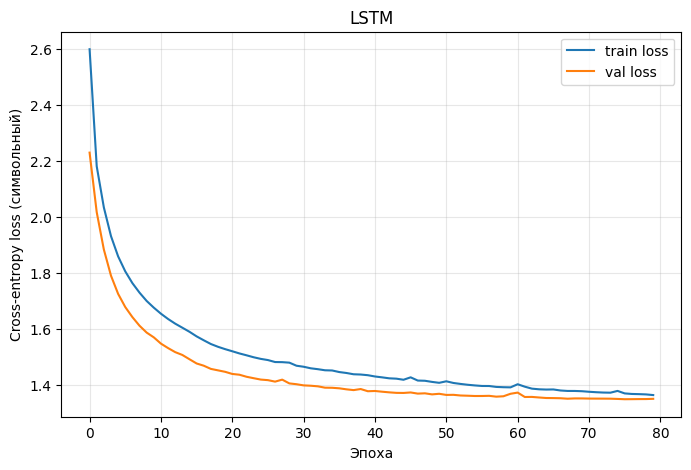

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("Эпоха")
plt.ylabel("Cross-entropy loss (символьный)")
plt.title("LSTM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()




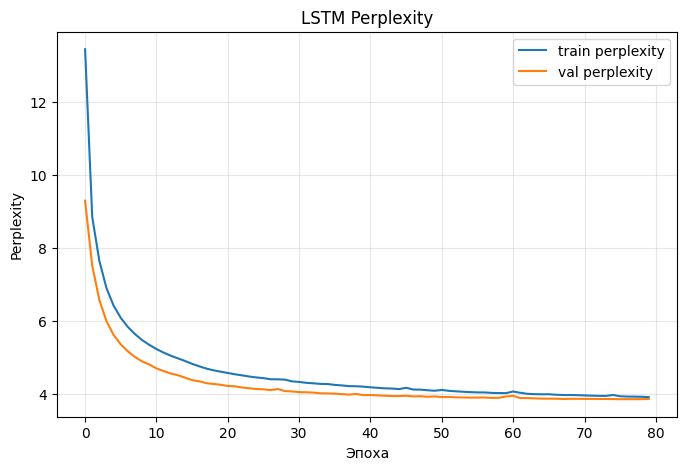

Итоговая perplexity на валидации (последняя эпоха): 3.859372274050498
Лучшая perplexity на валидации: 3.8539096869791942


In [34]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_ppl"], label="train perplexity")
plt.plot(history["val_ppl"], label="val perplexity")

plt.xlabel("Эпоха")
plt.ylabel("Perplexity")
plt.title("LSTM Perplexity")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print(f"Итоговая perplexity на валидации (последняя эпоха): {history['val_ppl'][-1]}")
print(f"Лучшая perplexity на валидации: {min(history['val_ppl'])}")

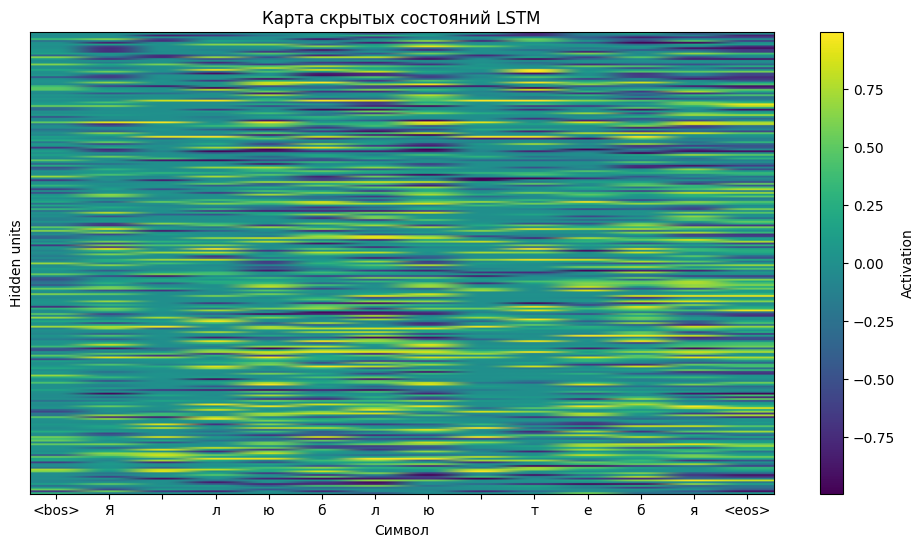

In [ ]:
model.eval()

text = "Я люблю тебя"
ids = torch.tensor([encode(text)], dtype=torch.long).to('cpu')

with torch.no_grad():
    emb = model.embedding(ids)
    out, (h, c) = model.lstm(emb)

hidden = out.squeeze(0).cpu().numpy().T  

tokens = ["<bos>"] + list(text) + ["<eos>"]

plt.figure(figsize=(12,6))
plt.imshow(hidden, aspect="auto", cmap="viridis")
plt.colorbar(label="Activation")

plt.xticks(range(len(tokens)), tokens)
plt.yticks([])

plt.xlabel("Символ")
plt.ylabel("Hidden units")
plt.title("Карта скрытых состояний LSTM")
plt.show()

In [49]:
import torch.nn.functional as F

model.eval()

prompt = "Я люблю "

ids = torch.tensor([encode(prompt)], dtype=torch.long).to(device)

with torch.no_grad():
    logits, _ = model(ids)

last_logits = logits[0, -1]
probs = F.softmax(last_logits, dim=-1)

topk = torch.topk(probs, 10)

print(f"Префикс: {prompt}\n")
print("10 наиболее вероятных следующих символов:\n")

for idx, prob in zip(topk.indices, topk.values):
    ch = idx2char[idx.item()]
    print(f"{repr(ch):8s} {prob.item():.4f}")

Префикс: Я люблю 

10 наиболее вероятных следующих символов:

'а'      0.2310
'е'      0.1445
'́'      0.1416
' '      0.0911
'и'      0.0796
'о'      0.0502
'д'      0.0472
'р'      0.0303
'с'      0.0257
'в'      0.0249


In [39]:
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
model = CharLSTMLM(VOCAB_SIZE, pad_idx=PAD_IDX, **ckpt["config"]).to('cpu')
model.load_state_dict(ckpt["model_state"])
model.eval()


@torch.no_grad()
def generate_poem(model, max_len=400, temperature=0.8, top_k=30):
    model.eval()
    idx = torch.tensor([[BOS_IDX]], device='cpu')
    state = None
    out_chars = []
    for _ in range(max_len):
        logits, state = model(idx, state)
        logits = logits[0, -1] / temperature
        logits[PAD_IDX] = -float("inf")
        logits[BOS_IDX] = -float("inf") 
        k = min(top_k, logits.size(-1))
        topk_vals, topk_idx = torch.topk(logits, k)
        probs = F.softmax(topk_vals, dim=-1)
        choice = topk_idx[torch.multinomial(probs, 1)].item()
        if choice == EOS_IDX:
            break
        out_chars.append(idx2char[choice])
        idx = torch.tensor([[choice]], device='cpu')
    return "".join(out_chars)


def extract_quatrains(text, n_lines=4):
    lines = [l for l in text.split("\n") if l.strip()]
    quatrains = []
    for i in range(0, len(lines) - n_lines + 1, n_lines):
        chunk = lines[i:i + n_lines]
        if len(chunk) == n_lines:
            quatrains.append("\n".join(chunk))
    return quatrains


In [40]:
N_SAMPLES = 30  

all_quatrains = []
for i in range(N_SAMPLES):
    poem = generate_poem(model)
    qs = extract_quatrains(poem)
    all_quatrains.extend(qs)
    print(f"Сгенерированный стих {i + 1}")
    print(poem)
    print()



Сгенерированный стих 1
Предста́л я ва́ших ме́шен и седо́й, -
Она́ прибе́га и осве́т.
Я у земли́, побе́ды от трево́жной
Далё́кий, не забы́вши зло́.
И я́ люби́л он вспо́мнил и́х -
Все в се́рдце си́нею весны́.

От бе́рега любви́ светло́.
Как в небеса́х - не дру́жны всю́ду.

Сгенерированный стих 2
Желе́за и обра́тно ве́шним са́дом
Доро́га го́род то́лько не держа́ть,
Наш мо́лодость в припо́мнит пы́ль сердца́,
И вну́кае печа́льные паху́чи.
Но тру́дно зна́ет мне́ предле́стьем
Во мне́ поты́лит се́рдце вла́сть больно́й.

Он и хоте́л ты - все́ судьба́
Не ве́сь ува́ - цвето́к луга́.
Когда́, под вы́полном свое́й други́х
И не по са́мым ми́ра на́м.

До зна́ет - бу́дет на судьбе́,
Молча́нье бе́лый; не

Сгенерированный стих 3
Мы́ прони́клы ме́сто пе́сней предстаё́т,
Ко́нчал я́сно. Дре́вно позабу́ду бы́ло -
И погу́бит со́н - её́ дале́кий
Сво́й весе́лья - во́дской - ка́ждый зве́рь.

До́лго бы́ло па́хнет на поэ́та,
Ка́к крова́во кра́ски, а отца́,
О́, она́ посме́рти без укра́шен,
На трево́гах упаде́нья та

In [ ]:
with open("vocab.json", "w", encoding="utf-8") as f:
    json.dump({"char2idx": char2idx,"config": ckpt["config"],}, f, ensure_ascii=False, indent=2)

with open("generated.json", "w", encoding="utf-8") as f:
    json.dump(all_quatrains, f, ensure_ascii=False, indent=2)


In [43]:
print(" - vocab.json                (словарь символов и конфиг модели)")
print(" - generated.json  (сгенерированные четверостишия)")


 - vocab.json                (словарь символов и конфиг модели)
 - generated.json  (сгенерированные четверостишия)
